In [2]:
import sys
import numpy as np
from pathlib import Path
from pyPolCal.csv_tools import read_csv,read_csv_physical_model_all_bins, write_fits_info_to_csv
from pyPolCal.fitting import *
from pyPolCal.utils import *
from pyPolCal.plotting import plot_data_and_model
from pyMuellerMat.physical_models.charis_physical_models import *
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt
import pandas as pd
# Plot settings that I like
plt.rcParams.update({
    #"text.usetex": True,
    #"font.family": "serif",
   # "font.serif": ["Palatino"],
    "font.size": 16,
   # "text.latex.preamble": r"\usepackage{amsmath}\usepackage{mathpazo}"
})
from pyPolCal.constants import wavelength_bins


# Step 1: Write FITS Info to CSV

This CSV writer will organize all relevant header information. Some header information is excluded from the extracted cubes but exists in the raw files. This function will match the info from raw headers by matching tags in the filenames. The CHARIS DPP rewrites these tags, so if you used the DPP at any point you will need to retitle all the frames to their original titles (there is a function in csv_tools.py to do this).

In [2]:
# Get paths to both processed and raw data 
# Make sure these directories have cubes with corresonding numbers
cube_dir = '/home/shared/exoserver/CHARIS-cals/new_data/cubes/pick_in'
csv_dir = '../datacsvs/pre_nbs_internalcal_pol_pick_in'

# Write all bins to csvs
for bin in range(0,22):
   csv_filepath = f'../datacsvs/pre_nbs_internalcal_pol_pick_in/bin{bin}.csv'
   write_fits_info_to_csv(cube_dir, csv_filepath,bin)



CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_in/bin0.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_in/bin1.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_in/bin2.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_in/bin3.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_in/bin4.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_in/bin5.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_in/bin6.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_in/bin7.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_in/bin8.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_in/bin9.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_in/bin10.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_in/bin11.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_in/bin12.csv
CSV file written to ../datacsvs/pre_nbs_internal

# Step 2 (Optional): Plot Your Data With the Original Model 

The csv reader will read in `interleaved_values`: interleaved single differences and sums `[differences, sums...]`, `interleaved_stds`:poissan noise propagated standard deviations (which are not used anymore and is an artifact of old code), and a `configuration_list` of dictionaries where each dictionary represents the instrument configuration for a measurement. The rationale for assuming no noise is that it is so tiny when normalized over large numbers of pixels it is irrelevant. It also improves fit accuracy.

In [3]:
# Define a csv filepath that we just created from whatever wavelength bin you want to visualize
# Weird things happen at the very lowest bins, so I recommend something more in the middle
filepath = Path('../datacsvs/pre_nbs_internalcal_pol_pick_in/bin15.csv')
# Read in data

interleaved_values, interleaved_stds, configuration_list = read_csv(filepath)
print("Interleaved Values")
print("Length: ", len(interleaved_values))
print(interleaved_values[0 : 10])
print("Interleaved Stds")
print("Length: ", len(interleaved_stds))
print(interleaved_stds[0 : 10])
print("Configuration List")
print("Length: ", len(configuration_list))
print(configuration_list[0 : 10])
print(interleaved_stds[0])

Interleaved Values
Length:  128
[-2.10164910e+08  4.02450338e+08  2.34711307e+08  4.00370202e+08
 -1.57108534e+08  4.00912593e+08  1.92660991e+08  3.98522867e+08
 -9.81105979e+06  3.98605969e+08]
Interleaved Stds
Length:  128
[20061.16491699 20061.16491699 20009.25291121 20009.25291121
 20022.80182534 20022.80182534 19963.03752303 19963.03752303
 19965.11880708 19965.11880708]
Configuration List
Length:  64
[{'hwp': {'theta': 0.0}, 'image_rotator': {'theta': 45.00033}}, {'hwp': {'theta': 45.0}, 'image_rotator': {'theta': 45.00029}}, {'hwp': {'theta': 11.25}, 'image_rotator': {'theta': 45.00029}}, {'hwp': {'theta': 56.25}, 'image_rotator': {'theta': 45.00029}}, {'hwp': {'theta': 22.5}, 'image_rotator': {'theta': 45.00029}}, {'hwp': {'theta': 67.5}, 'image_rotator': {'theta': 45.00029}}, {'hwp': {'theta': 33.75}, 'image_rotator': {'theta': 45.00029}}, {'hwp': {'theta': 78.75}, 'image_rotator': {'theta': 45.00029}}, {'hwp': {'theta': 0.0}, 'image_rotator': {'theta': 57.49991}}, {'hwp': {'

The Mueller matrix chain is contained in a pyMuellerMat system Mueller matrix object. These are generated using configuration dictionaries with the below format. You can generate a system dictionary with any function listed in the common_mm_functions.py script in the pyMuellerMat physical_models branch (can be found here: https://github.com/maxwellmb/pyMuellerMat/tree/physical_models/pyMuellerMat). Each component is within a `components` dictionary, listed from downstream to upstream. You can name each component, and give it a `type` which is the name of the commmon mm function. The `properties` are the case sensitive inputs to these functions. Tag each component as `internal`. With this system dict you can create your Mueller matrix with `generate_system_mueller_matrix()`.

In [4]:

# Loading in past fits 

offset_imr = 0.18563 # derotator offset
offset_hwp = -0.87823 # HWP offset
offset_cal = -0.44630 # calibration polarizer offset
imr_theta = 0
hwp_theta = 0



# Define instrument configuration as system dictionary
# Wollaston beam, imr theta/phi, and hwp theta/phi will all be updated within functions, so don't worry about their values here

system_dict = {
        "components" : {
            "wollaston" : {
            "type" : "wollaston_prism_function",
            "properties" : {"beam": 'o'}, 
            "tag": "internal",
            },
            "image_rotator" : {
                "type" : "elliptical_retarder_function",
                "properties" : {"phi_h": 1, "theta": imr_theta, "delta_theta": offset_imr},
                "tag": "internal",
            },
            "hwp" : {
                "type" : "general_retarder_function",
                "properties" : {"phi": 0, "theta": hwp_theta, "delta_theta": offset_hwp},
                "tag": "internal",
            },
            "lp" : {  # calibration polarizer for internal calibration source
                "type": "diattenuator_retarder_function",
                "properties": {"epsilon": -1, "delta_theta": offset_cal},
                "tag": "internal"},
            
        }}
    

# Converting system dictionary into system Mueller Matrix object

system_mm = generate_system_mueller_matrix(system_dict)
evaluated_mm = system_mm.evaluate()
s_in = [1,0,0,0]
s_out = evaluated_mm @ s_in
print(s_out)



[9.3523637e-05 9.3523637e-05 0.0000000e+00 0.0000000e+00]


Here is where we can load in our old fit. The fit I have loaded in is my median posterior MCMC fit of the Joost 't Hart 2021 physical model. The physical model is contained in functions from the physical_models branch of pyMuellerMat. The fit is not very good, which prompted the switch to an elliptical polarizer model for the derotator. `p` and `system_parameters` are updates that will be placed into the Mueller matrix. This is because plotting function is made to use the same workflow as `minimize_system_mueller_matrix()` (If you would prefer to work without my wrapper function, follow the same procedure here to generate the model).

`p` is the float values of the parameters detailed in `system_parameters` which contains the float value's component name and what `property` it is in the `system_dict`. `modeled_interleaved` are the modeled single sums and differences generated from the `system_mm` and updated p values, which we then process into double sums and differences using `process_model()`. Note that, for CHARIS, the sums are irrelevant. `plot_data_and_model()` plots the double differences vs. HWP angle for all derotator angles. 

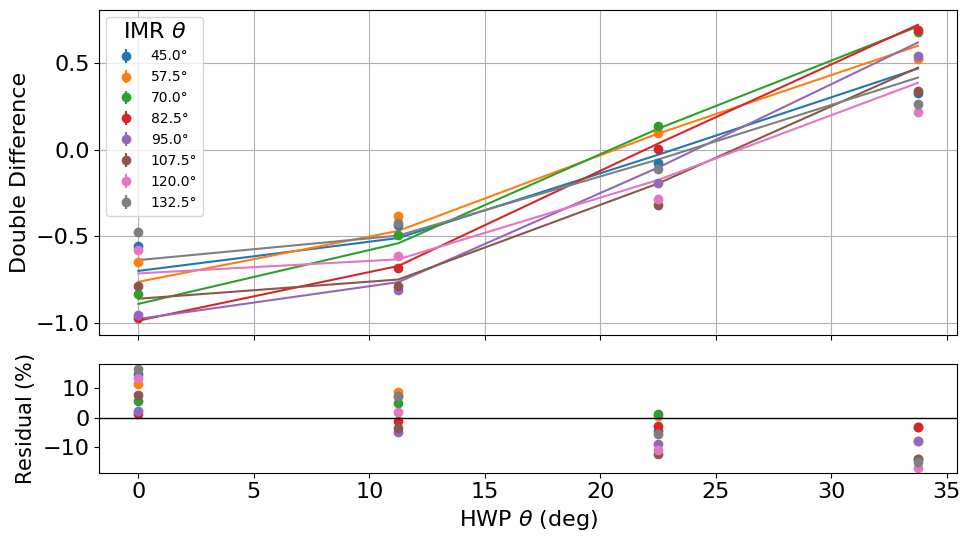

[-0.70063954 -0.51064997 -0.02914219  0.46914723 -0.7635794  -0.46917775
  0.09318242  0.60069606 -0.89121899 -0.5409191   0.12138789  0.71240272
 -0.98792139 -0.67216503  0.03541353  0.72217422 -0.9781451  -0.76558496
 -0.10318473  0.61971173 -0.86162977 -0.75043296 -0.19523536  0.47449602
 -0.71493282 -0.63384091 -0.17483536  0.38683797 -0.63799862 -0.49642095
 -0.05645769  0.41686623]
[np.float64(3.0570640046313304), np.float64(0.8357196966340271)] [['hwp', 'phi'], ['image_rotator', 'phi_h']]


In [5]:

# Get our model retardances from Joost t Hart physical models

p = [HWP_retardance(wavelength_bins,1.66725,1.30159)[15], IMR_retardance(wavelength_bins,259.14673)[15]]


# Define what is in the p list

system_parameters = [['hwp', 'phi'], ['image_rotator', 'phi_h']]

# Generate our modeled left and right beam intensities

modeled_interleaved = model(p, system_parameters, system_mm, configuration_list)

# Process these into interleaved single norm differences and sums

diffs_sums = process_model(modeled_interleaved)

# Plot the modeled and observed values

fig, ax = plot_data_and_model(interleaved_values, diffs_sums,configuration_list, wavelength= wavelength_bins[15],include_sums=False,title='')
ax.tick_params(
    axis='x',
    direction='in',
    top=True,
    which='both',  
)
ax.tick_params(
    axis='y',
    direction='in',
    right=True,
    which='both',
)
ax.minorticks_on()
#fig.savefig('/Users/thomasmcintosh/Desktop/CHARIS-REU/overleaf_plots/MCMC_model_single_diff_vs_hwp_1932.png',bbox_inches='tight', dpi=600)
diffs = process_dataset(interleaved_values)[::2]
print(diffs_sums[::2])
pol_acc = np.sqrt(np.sum((diffs*100-diffs_sums[::2]*100)**2)/(len(diffs)-6))
pol_acc
print(p, system_parameters)

# Step 3: Fit for Retardances

ABOUT THE FITTING FUNCTION/HOW I USE IT: I made a function that does everything quickly but is also tailored to the parameters I am fitting. My function fits using scipy least squares, updates the model, puts the pyMuellerMat compatible system dictionary in a JSON file, and optionally saves a plot of the model vs data to a specified path.
If you want to use it for different parameters than the ones in the p0 dictionary within the function, 
you'll have to update the function a bit (which shouldn't take too long). This is a wrapper function for the main minimization function in fitting.py. I've found it easier to use this function and tailor the parameters that it's fitting to what I need instead of using that fitting function. The things you need to edit in this function in instruments.py to fit new parameters are marked with all caps comments that look like this: # IF YOU WANT TO MODIFY YOUR PARAMETERS, EDIT THIS

This funciton calculates s_res, which is a metric used in previous polcal papers to quantify goodness of fit. It's essentially a corrected average of residuals. It also calculates error on fit from a Jacobian estimation technique from Rob Van Holstein's 2020 VLT SPHERE polcal paper.

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.7416e-01                                    8.00e+00    
       1              2         1.1390e-03      1.73e-01       2.18e-01       6.49e-01    
       2              3         8.7484e-05      1.05e-03       1.35e-02       5.45e-04    
       3              4         4.3316e-05      4.42e-05       3.61e-03       5.44e-05    
       4              5         4.1113e-05      2.20e-06       8.51e-04       3.81e-06    
       5              6         4.1101e-05      1.28e-08       6.94e-05       2.53e-08    
       6              7         4.1101e-05      5.71e-13       4.68e-07       8.95e-11    
`gtol` termination condition is satisfied.
Function evaluations 7, initial cost 1.7416e-01, final cost 4.1101e-05, first-order optimality 8.95e-11.
     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [-6.298e-04  1.230

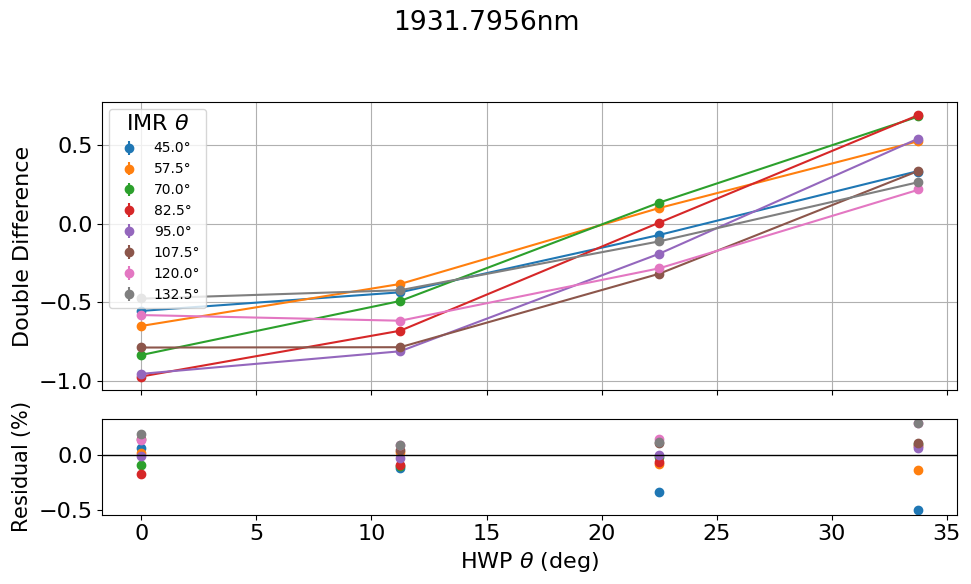

Updated Mueller Matrix:
[[ 0.65805845 -0.65805845  0.          0.        ]
 [-0.65506266  0.65506266  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.5077933423980383 0.28959478072776434
s_res: 0.17448459313363687
Error: [0.00080976 0.00053168 0.00109896 0.0018233  0.00064958]


/tmp/ipykernel_271176/3250571384.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


In [6]:
# Test fitting with the wavelength bin we plotted earlier
from pyPolCal.instruments import fit_CHARIS_Mueller_matrix_by_bin
error, fig2, ax2,sres = fit_CHARIS_Mueller_matrix_by_bin(filepath, 15, 
    Path('/home/thomasmc/nbs_in/pol/sys_dicts/test.json'),
    )
ax2.tick_params(
    axis='x',
    direction='in',
    top=True,
    which='both',  
)
ax2.tick_params(
    axis='y',
    direction='in',
    right=True,
    which='both',
)
ax2.minorticks_on()
fig2.suptitle('')
fig2.show()
#fig2.savefig('/Users/thomasmcintosh/Desktop/CHARIS-REU/overleaf_plots/naive_model_single_diff_vs_hwp_1932.png',bbox_inches='tight', dpi=600)



The elliptical IMR model is a huge improvement! Now we can fit for all bins. In this fit, I'm fitting for 3 elliptical retarder parameters and a Wollaston prism modulator term.

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.8232e-02                                    3.69e+00    
       1              2         5.9547e-03      7.23e-02       2.56e-01       4.67e-01    
       2              3         4.9713e-03      9.83e-04       1.97e-02       3.93e-03    
       3              4         4.9704e-03      9.83e-07       1.47e-03       5.97e-05    
       4              5         4.9704e-03      1.82e-10       2.04e-05       1.68e-06    
       5              6         4.9704e-03      1.21e-13       5.30e-07       3.93e-08    
`ftol` termination condition is satisfied.
Function evaluations 6, initial cost 7.8232e-02, final cost 4.9704e-03, first-order optimality 3.93e-08.
     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-4.563e-05  6.602e-03 ...  3.073e-02  1.551e-02]
           x: [ 4.339e+00  4.127e-26  2.183e-01  3.009e+00 

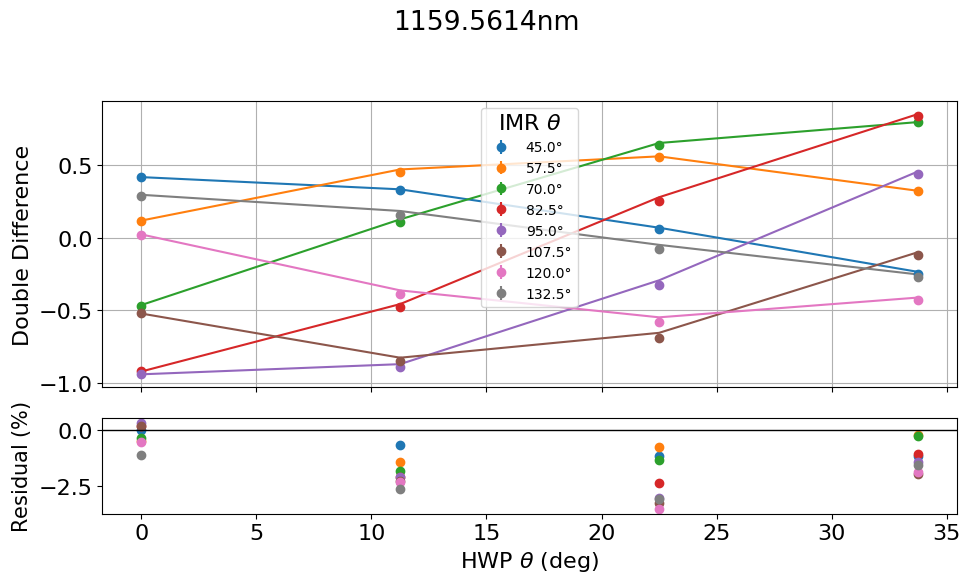

Updated Mueller Matrix:
[[ 0.33182112 -0.33182112  0.          0.        ]
 [-0.33182112  0.33182112  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -3.526066923377549 0.3312222474308584
s_res: 1.9187890866770805
Error: [0.00756267 0.0225844  0.01785231 0.01804185 0.00721162]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.0841e-01                                    3.20e+00    
       1              2         5.3270e-03      1.03e-01       2.70e-01       4.94e-01    
       2              3         3.2912e-03      2.04e-03       3.46e-02       1.95e-02    
       3              4         3.2885e-03      2.71e-06       1.15e-03       1.52e-05    
       4              5         3.2885e-03      2.83e-11       4.62e-06       1.25e-08    
`ftol` termination condition is satisfied.
Function evaluations 5, initia

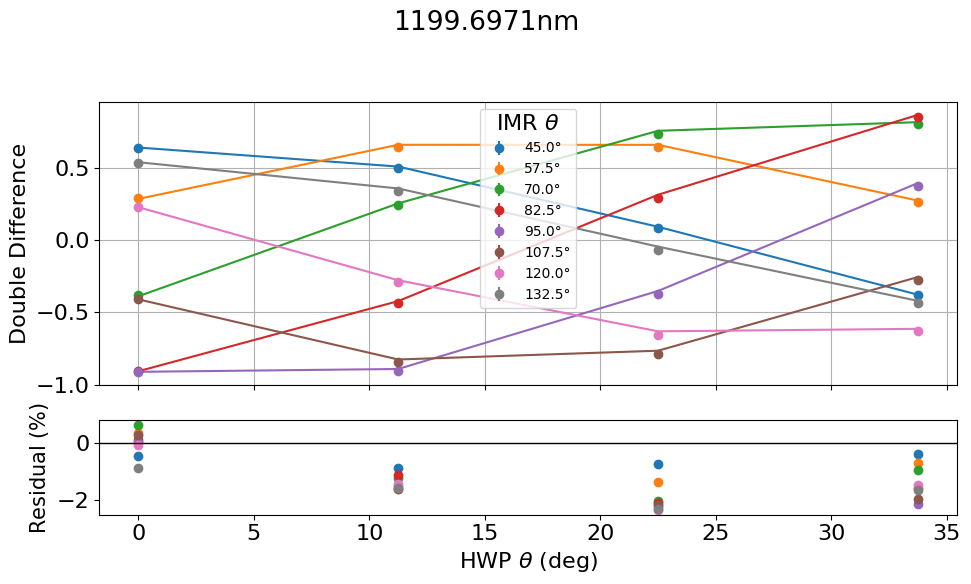

Updated Mueller Matrix:
[[ 0.25339281 -0.25339281  0.          0.        ]
 [-0.24442812  0.24442812  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -2.3610343010715837 0.6558493950932913
s_res: 1.5607469644412393
Error: [0.00808474 0.0203233  0.01168467 0.01737387 0.00588376]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.2937e-02                                    4.07e+00    
       1              2         2.8458e-03      7.01e-02       2.04e-01       2.05e-01    
       2              3         2.2401e-03      6.06e-04       2.42e-02       7.81e-03    
       3              4         2.2395e-03      5.89e-07       6.51e-04       7.23e-06    
       4              5         2.2395e-03      5.60e-12       2.17e-06       3.78e-09    
`gtol` termination condition is satisfied.
Function evaluations 5, initi

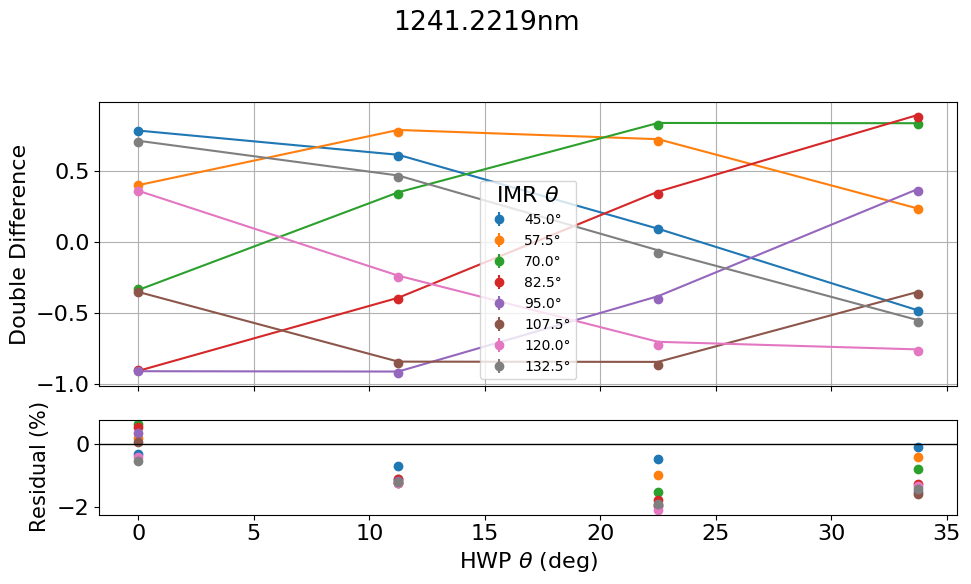

Updated Mueller Matrix:
[[ 0.19934194 -0.19934194  0.          0.        ]
 [-0.19287729  0.19287729  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -2.0948117459499684 0.6034294901481232
s_res: 1.287971765842471
Error: [0.00880423 0.01934306 0.00829075 0.0174844  0.00486   ]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.3637e-02                                    5.27e+00    
       1              2         1.0595e-03      8.26e-02       1.83e-01       1.99e-01    
       2              3         6.6685e-04      3.93e-04       1.77e-02       6.66e-04    
       3              4         6.6660e-04      2.50e-07       1.30e-04       9.93e-07    
       4              5         6.6660e-04      8.11e-13       9.91e-07       2.63e-10    
`gtol` termination condition is satisfied.
Function evaluations 5, initia

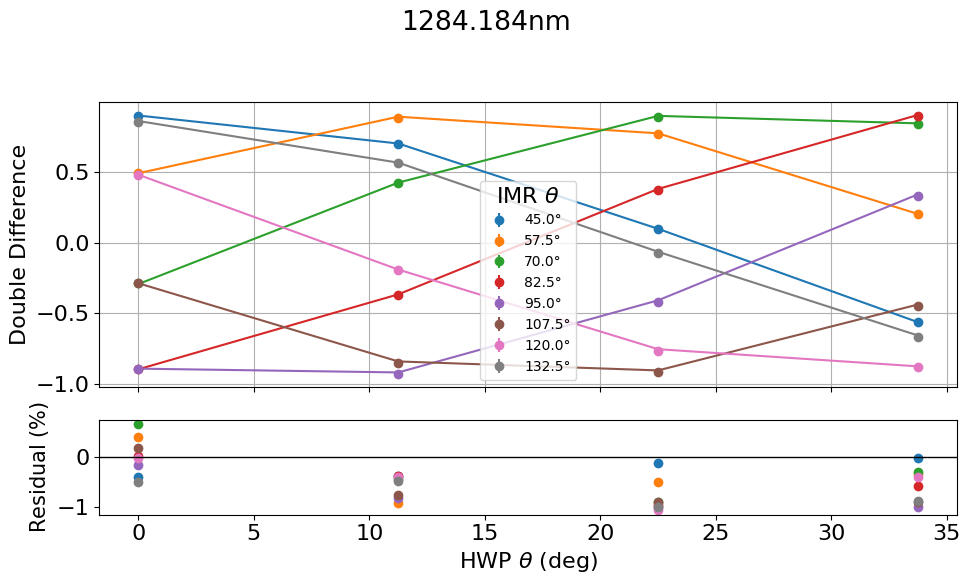

Updated Mueller Matrix:
[[ 0.15701987 -0.15701987  0.          0.        ]
 [-0.14204677  0.14204677  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.066997630777692 0.6424859618550336
s_res: 0.7026942832023558
Error: [0.007845   0.01483427 0.003955   0.01444269 0.0026681 ]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.8450e-02                                    6.04e+00    
       1              2         1.3427e-02      7.50e-02       3.97e-01       4.83e-01    
       2              3         1.3816e-03      1.20e-02       1.70e-01       6.59e-02    
       3              4         2.3770e-04      1.14e-03       1.76e-02       1.22e-03    
       4              5         8.1706e-05      1.56e-04       2.26e-02       1.92e-03    
       5              6         7.3757e-05      7.95e-06       4.39e-03  

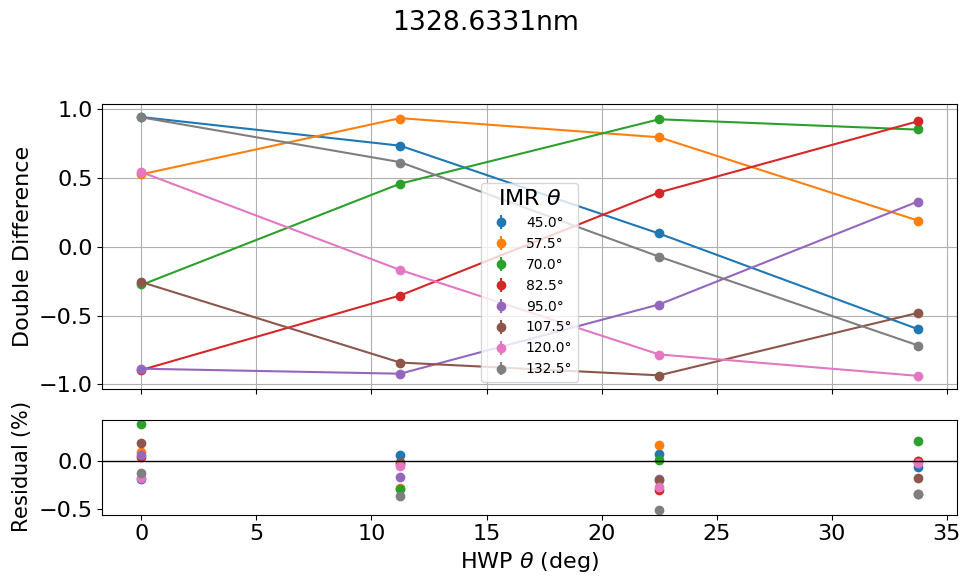

Updated Mueller Matrix:
[[ 0.13979967 -0.13979967  0.          0.        ]
 [-0.12413191  0.12413191  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.518186036010416 0.3880749738277558
s_res: 0.23365590679781595
Error: [0.00446785 0.00777664 0.00121745 0.00793729 0.00087269]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.3649e-02                                    6.00e+00    
       1              2         7.7918e-04      8.29e-02       2.08e-01       1.15e-01    
       2              3         1.6871e-04      6.10e-04       2.16e-02       1.87e-03    
       3              4         1.2833e-04      4.04e-05       7.35e-03       3.17e-04    
       4              5         1.2727e-04      1.06e-06       1.30e-03       1.04e-05    
       5              6         1.2727e-04      1.30e-09       4.75e-05 

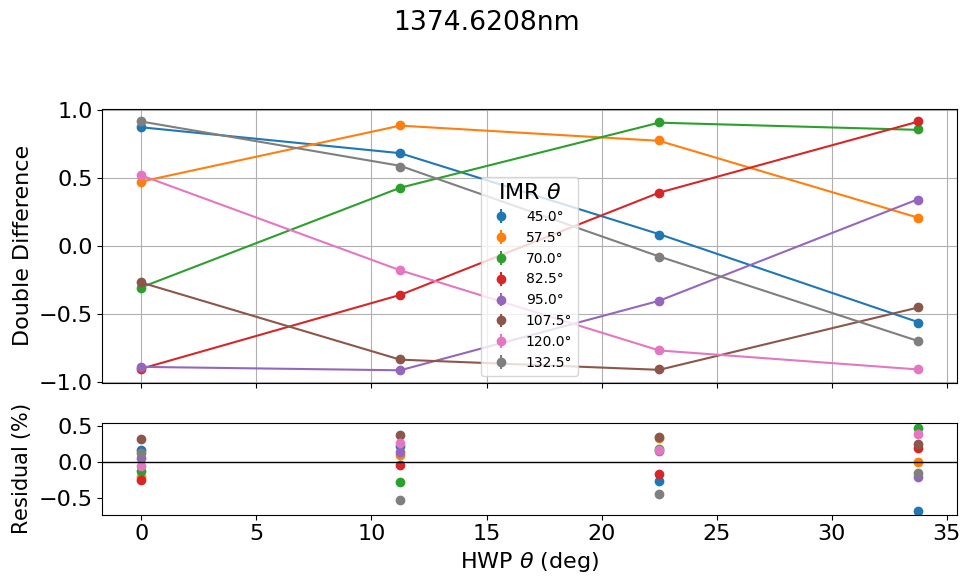

Updated Mueller Matrix:
[[ 0.1636661  -0.1636661   0.          0.        ]
 [-0.15063743  0.15063743  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.6796781099122313 0.475525707985625
s_res: 0.30704192366531063
Error: [0.00370638 0.0052577  0.00130389 0.00676337 0.00117182]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         6.7504e-02                                    5.68e+00    
       1              2         5.4568e-04      6.70e-02       1.32e-01       1.78e-01    
       2              3         3.3513e-04      2.11e-04       1.68e-02       1.25e-04    
       3              4         3.3306e-04      2.06e-06       1.29e-03       1.51e-05    
       4              5         3.3306e-04      3.38e-09       5.08e-05       1.17e-07    
       5              6         3.3306e-04      1.17e-14       9.14e-08 

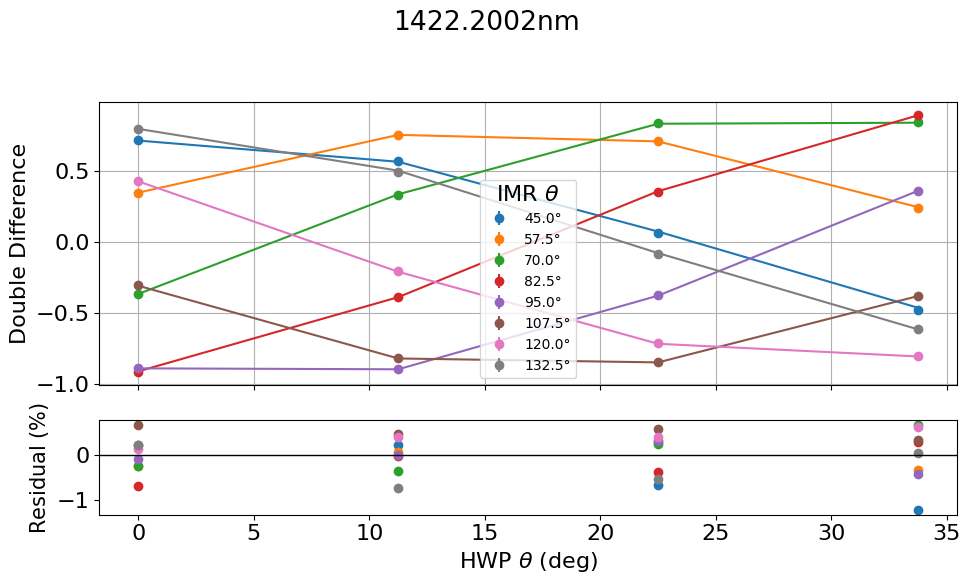

Updated Mueller Matrix:
[[ 0.21893884 -0.21893884  0.          0.        ]
 [-0.20546909  0.20546909  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.2349661163835535 0.6649882916578882
s_res: 0.4967012238668816
Error: [0.00361804 0.00502399 0.00204457 0.00710312 0.001878  ]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.2403e-02                                    4.72e+00    
       1              2         5.5190e-04      4.19e-02       1.05e-01       1.54e-01    
       2              3         4.7518e-04      7.67e-05       6.02e-03       2.42e-04    
       3              4         4.7443e-04      7.56e-07       5.62e-04       3.79e-06    
       4              5         4.7442e-04      6.17e-10       1.64e-05       4.73e-08    
       5              6         4.7442e-04      4.76e-16       1.42e-08 

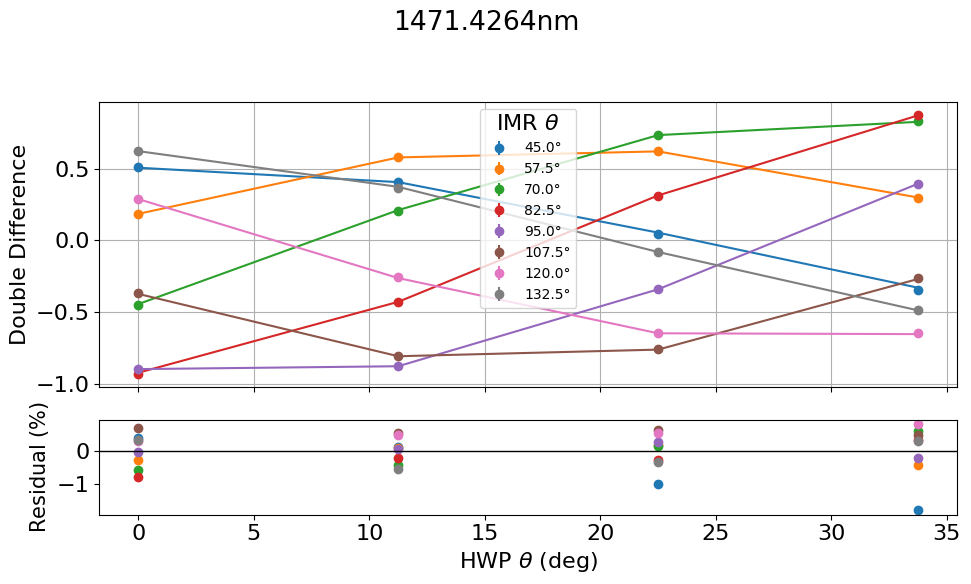

Updated Mueller Matrix:
[[ 0.29269438 -0.29269438  0.          0.        ]
 [-0.28173738  0.28173738  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.772827934709042 0.7909520471888243
s_res: 0.5928115263239928
Error: [0.00298187 0.00409648 0.00243326 0.00650542 0.00222588]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.7376e-02                                    3.59e+00    
       1              2         5.7588e-04      2.68e-02       9.37e-02       9.84e-02    
       2              3         5.2484e-04      5.10e-05       4.51e-03       8.62e-05    
       3              4         5.2440e-04      4.42e-07       3.77e-04       1.46e-06    
       4              5         5.2440e-04      1.76e-10       7.64e-06       2.21e-08    
       5              6         5.2440e-04      3.42e-17       3.33e-09  

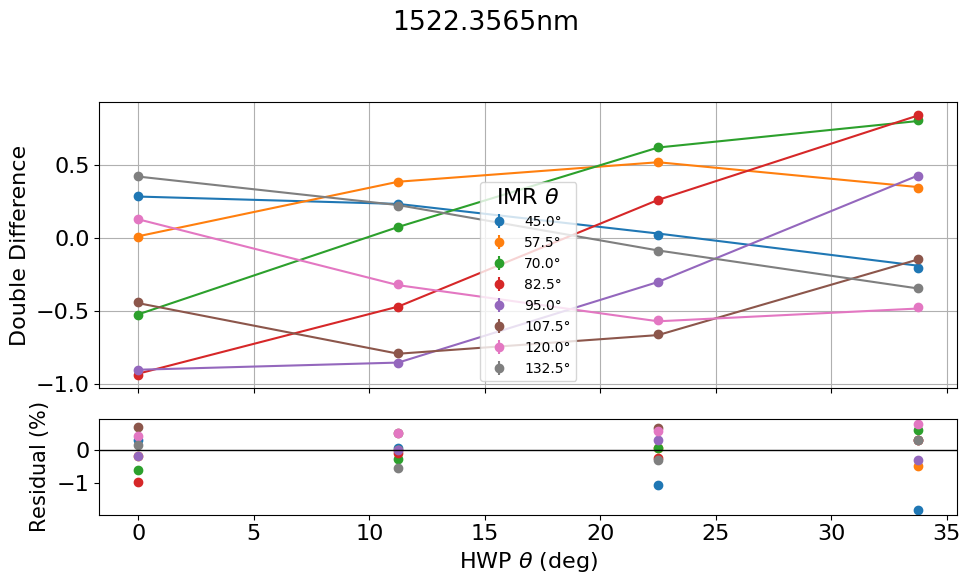

Updated Mueller Matrix:
[[ 0.37054495 -0.37054495  0.          0.        ]
 [-0.3598372   0.3598372   0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.8475516495395965 0.8120011775915685
s_res: 0.6232515352709981
Error: [0.00249378 0.00335094 0.00263527 0.00599398 0.00233478]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.6069e-02                                    2.83e+00    
       1              2         5.0688e-04      3.56e-02       1.07e-01       1.28e-01    
       2              3         4.2316e-04      8.37e-05       5.24e-03       7.67e-05    
       3              4         4.2214e-04      1.02e-06       5.32e-04       1.96e-06    
       4              5         4.2214e-04      1.20e-09       1.87e-05       3.95e-08    
       5              6         4.2214e-04      1.91e-15       2.36e-08 

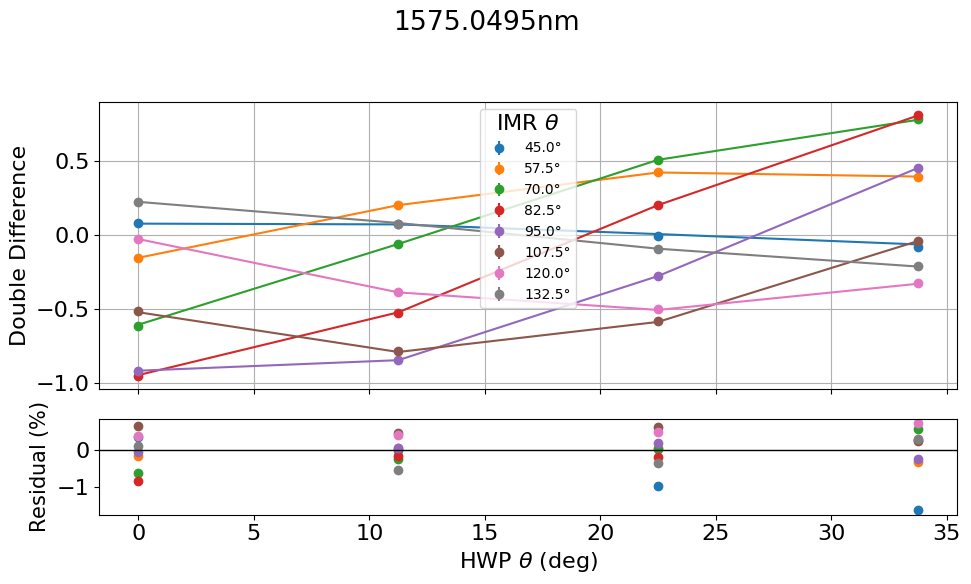

Updated Mueller Matrix:
[[ 0.44198239 -0.44198239  0.          0.        ]
 [-0.43389017  0.43389017  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.6376820167725556 0.7414917063093647
s_res: 0.5591909960791147
Error: [0.00198459 0.00251906 0.00247325 0.00506522 0.00209117]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.2876e-02                                    3.28e+00    
       1              2         6.1954e-04      5.23e-02       1.20e-01       2.31e-01    
       2              3         4.6931e-04      1.50e-04       6.40e-03       1.48e-04    
       3              4         4.6812e-04      1.20e-06       5.65e-04       2.80e-06    
       4              5         4.6812e-04      1.40e-09       1.99e-05       5.93e-08    
       5              6         4.6812e-04      2.19e-15       2.49e-08 

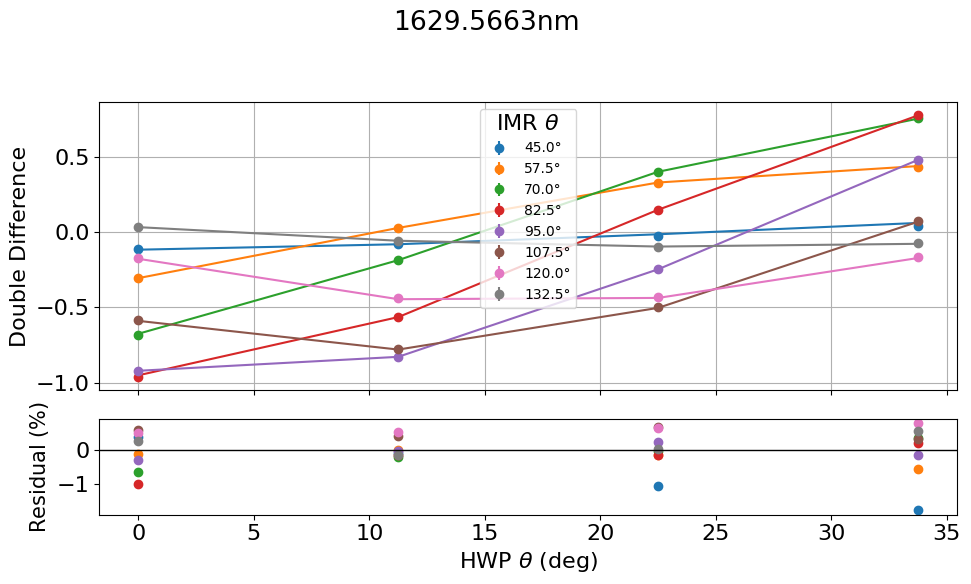

Updated Mueller Matrix:
[[ 0.50973291 -0.50973291  0.          0.        ]
 [-0.50202278  0.50202278  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.7527151253476845 0.7711837812241313
s_res: 0.5888582372225994
Error: [0.00204059 0.00232147 0.00278808 0.00528528 0.00219979]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.4918e-02                                    4.52e+00    
       1              2         6.0335e-04      7.43e-02       1.34e-01       3.32e-01    
       2              3         3.6596e-04      2.37e-04       7.40e-03       1.87e-04    
       3              4         3.6413e-04      1.82e-06       7.09e-04       4.37e-06    
       4              5         3.6413e-04      3.44e-09       3.17e-05       9.17e-08    
       5              6         3.6413e-04      1.45e-14       6.53e-08 

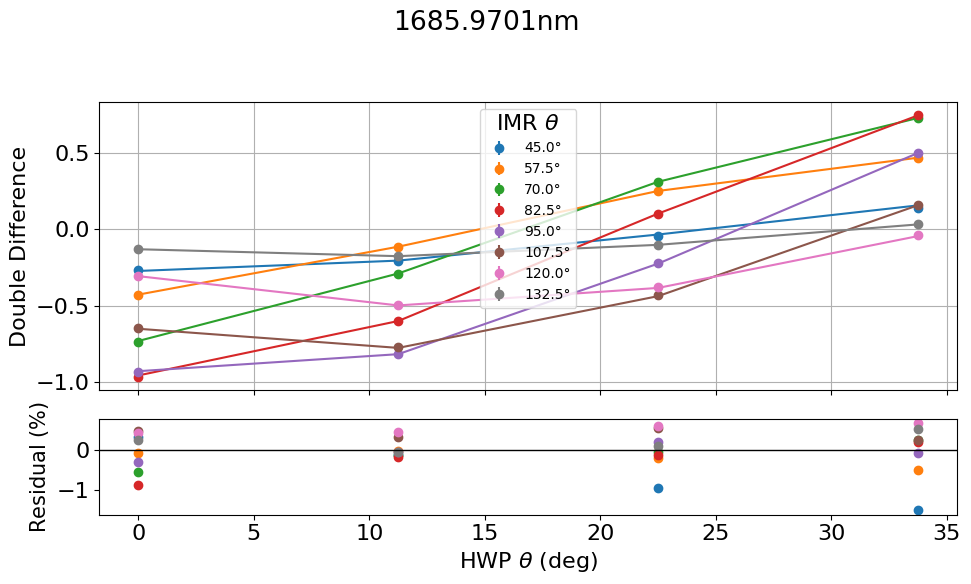

Updated Mueller Matrix:
[[ 0.56327735 -0.56327735  0.          0.        ]
 [-0.55674435  0.55674435  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.5197938317109099 0.6730721433587998
s_res: 0.519351813149678
Error: [0.00187961 0.00186279 0.00264352 0.00475912 0.00193838]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.0976e-01                                    5.63e+00    
       1              2         5.9734e-04      1.09e-01       1.61e-01       4.46e-01    
       2              3         2.0044e-04      3.97e-04       8.97e-03       2.29e-04    
       3              4         1.9509e-04      5.35e-06       1.24e-03       8.97e-06    
       4              5         1.9505e-04      3.56e-08       1.05e-04       2.07e-07    
       5              6         1.9505e-04      2.23e-12       8.32e-07  

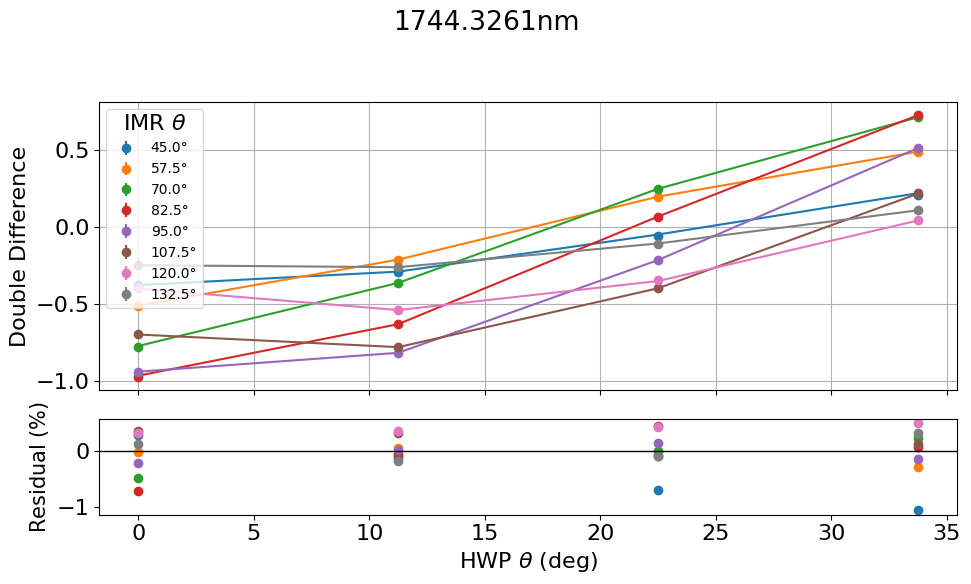

Updated Mueller Matrix:
[[ 0.59832391 -0.59832391  0.          0.        ]
 [-0.593356    0.593356    0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.0569268483227603 0.490694233620645
s_res: 0.3801097200326596
Error: [0.00146157 0.00128308 0.00205379 0.00358555 0.00141736]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.4126e-01                                    6.69e+00    
       1              2         8.0860e-04      1.40e-01       1.84e-01       5.55e-01    
       2              3         1.9833e-04      6.10e-04       1.06e-02       2.76e-04    
       3              4         1.8703e-04      1.13e-05       1.88e-03       1.76e-05    
       4              5         1.8690e-04      1.32e-07       2.07e-04       4.79e-07    
       5              6         1.8690e-04      2.91e-11       3.12e-06  

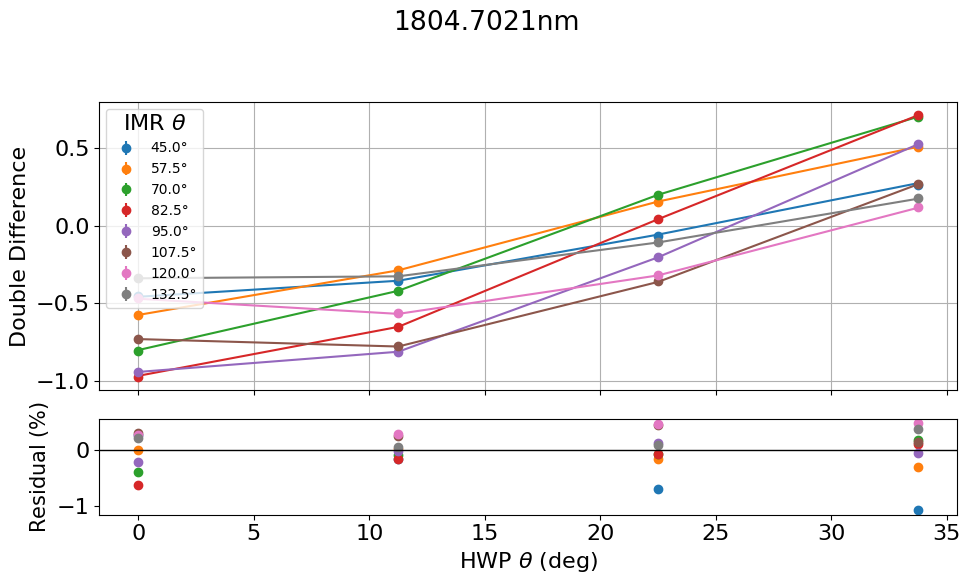

Updated Mueller Matrix:
[[ 0.62613917 -0.62613917  0.          0.        ]
 [-0.62146805  0.62146805  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.0809788983288549 0.47175154737942826
s_res: 0.3720800831491844
Error: [0.00153709 0.00120241 0.00213682 0.00364706 0.00138644]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.5434e-01                                    7.47e+00    
       1              2         9.3097e-04      1.53e-01       1.97e-01       6.02e-01    
       2              3         1.5323e-04      7.78e-04       1.16e-02       3.34e-04    
       3              4         1.3092e-04      2.23e-05       2.64e-03       3.17e-05    
       4              5         1.3038e-04      5.33e-07       4.25e-04       1.00e-06    
       5              6         1.3038e-04      5.74e-10       1.44e-05

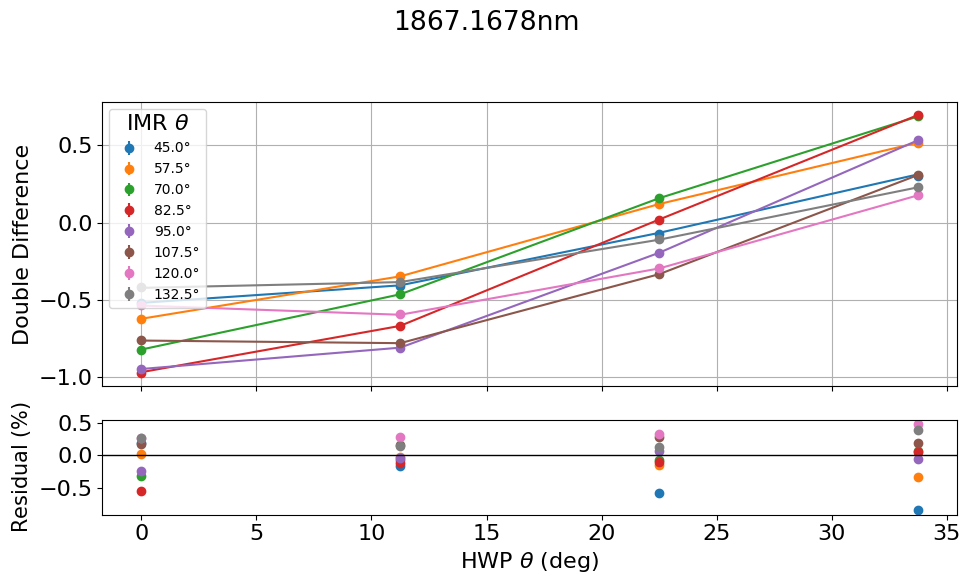

Updated Mueller Matrix:
[[ 0.64688704 -0.64688704  0.          0.        ]
 [-0.64302341  0.64302341  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.8368344729105957 0.4720690650019286
s_res: 0.31077314910048165
Error: [0.00137697 0.00096842 0.00188773 0.003165   0.00115722]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.7416e-01                                    8.00e+00    
       1              2         1.1390e-03      1.73e-01       2.18e-01       6.49e-01    
       2              3         8.7484e-05      1.05e-03       1.35e-02       5.45e-04    
       3              4         4.3316e-05      4.42e-05       3.61e-03       5.44e-05    
       4              5         4.1113e-05      2.20e-06       8.51e-04       3.81e-06    
       5              6         4.1101e-05      1.28e-08       6.94e-05

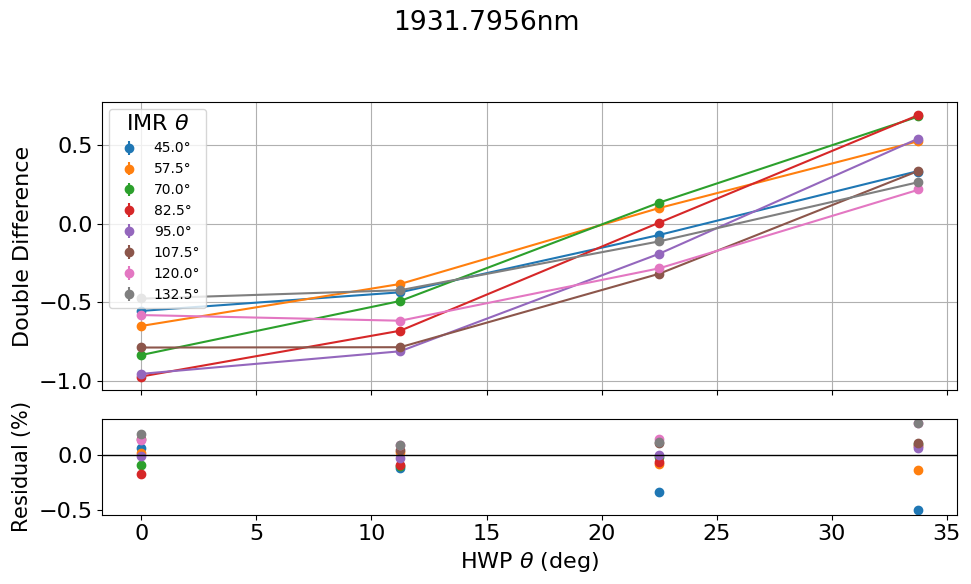

Updated Mueller Matrix:
[[ 0.65805845 -0.65805845  0.          0.        ]
 [-0.65506266  0.65506266  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.5077933423980383 0.28959478072776434
s_res: 0.17448459313363687
Error: [0.00080976 0.00053168 0.00109896 0.0018233  0.00064958]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.9865e-01                                    8.49e+00    
       1              2         1.6056e-03      1.97e-01       2.43e-01       7.07e-01    
       2              3         1.0545e-04      1.50e-03       1.66e-02       9.76e-04    
       3              4         2.2812e-05      8.26e-05       4.75e-03       8.60e-05    
       4              5         1.5234e-05      7.58e-06       1.48e-03       1.12e-05    
       5              6         1.5050e-05      1.84e-07       2.62e-0

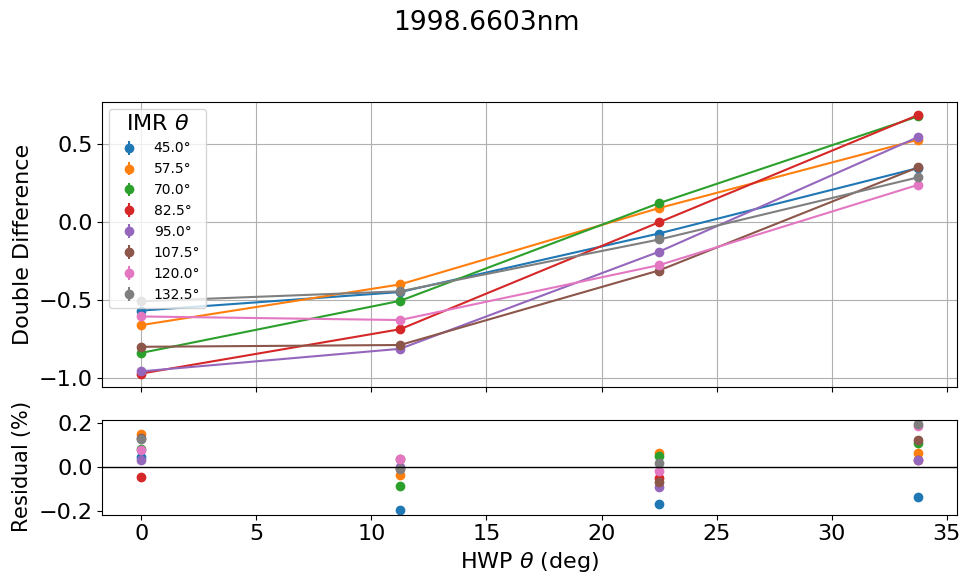

Updated Mueller Matrix:
[[ 0.66237512 -0.66237512  0.          0.        ]
 [-0.660145    0.660145    0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.1965654657934408 0.1951808877341925
s_res: 0.10558543355652632
Error: [0.00050284 0.00031751 0.00067832 0.00111872 0.00039314]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.1695e-01                                    8.76e+00    
       1              2         1.9415e-03      2.15e-01       2.58e-01       7.70e-01    
       2              3         1.0601e-04      1.84e-03       1.87e-02       1.21e-03    
       3              4         2.2498e-05      8.35e-05       5.27e-03       9.58e-05    
       4              5         1.7779e-05      4.72e-06       1.27e-03       7.94e-06    
       5              6         1.7739e-05      3.96e-08       1.26e-04

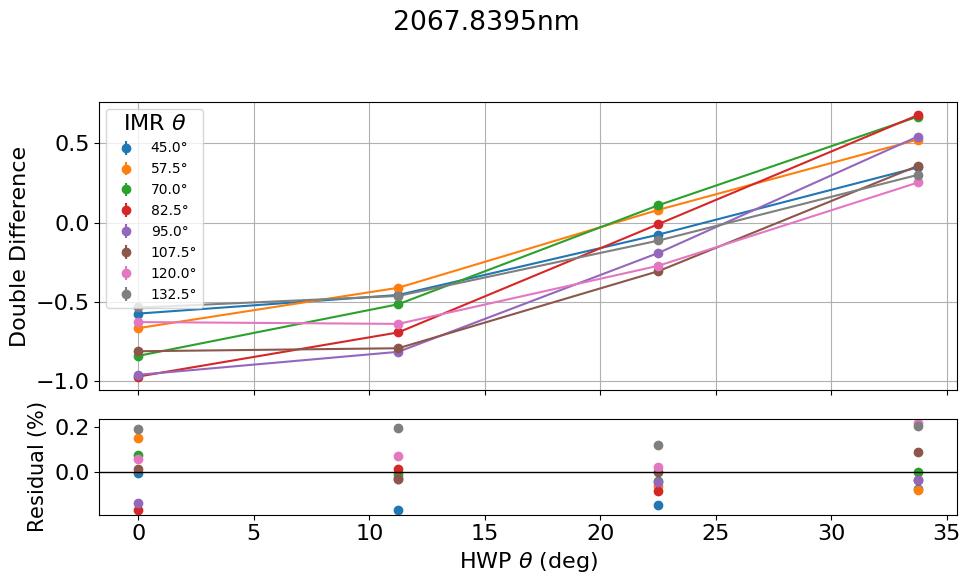

Updated Mueller Matrix:
[[ 0.66290161 -0.66290161  0.          0.        ]
 [-0.65942791  0.65942791  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.1688612100736293 0.21834333288485652
s_res: 0.11463058326900405
Error: [0.00055906 0.00034334 0.00075087 0.00123259 0.00042713]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.2806e-01                                    8.74e+00    
       1              2         2.2820e-03      2.26e-01       2.71e-01       7.81e-01    
       2              3         1.3355e-04      2.15e-03       2.06e-02       1.51e-03    
       3              4         2.5819e-05      1.08e-04       5.95e-03       1.16e-04    
       4              5         1.8576e-05      7.24e-06       1.54e-03       1.17e-05    
       5              6         1.8482e-05      9.38e-08       1.95e-0

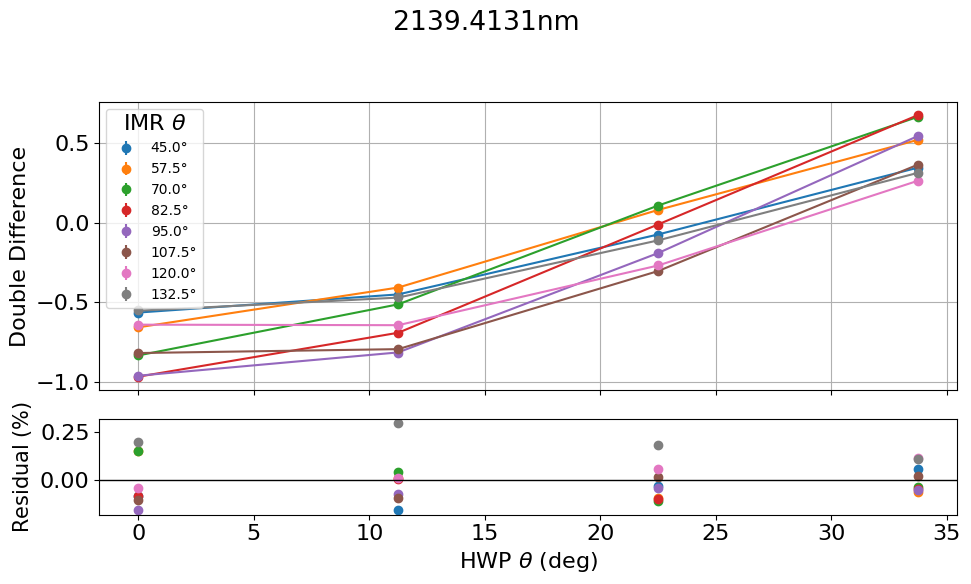

Updated Mueller Matrix:
[[ 0.66017016 -0.66017016  0.          0.        ]
 [-0.65684609  0.65684609  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.15599908991134726 0.29493204254634264
s_res: 0.11700539628719533
Error: [0.00057338 0.00034936 0.00076914 0.00125943 0.00043664]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.4907e-01                                    8.49e+00    
       1              2         2.5018e-03      2.47e-01       2.86e-01       8.21e-01    
       2              3         1.3494e-04      2.37e-03       2.20e-02       1.53e-03    
       3              4         4.2755e-05      9.22e-05       6.17e-03       1.07e-04    
       4              5         3.9805e-05      2.95e-06       1.04e-03       5.33e-06    
       5              6         3.9797e-05      8.12e-09       5.82e-

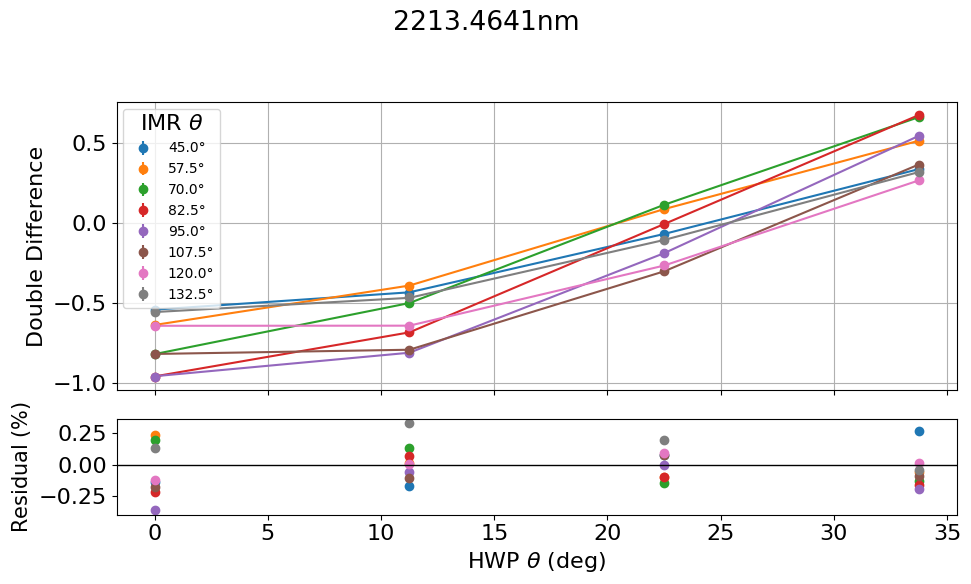

Updated Mueller Matrix:
[[ 0.65321556 -0.65321556  0.          0.        ]
 [-0.6478864   0.6478864   0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.3617139742444664 0.33134072494284794
s_res: 0.17169490677226582
Error: [0.00083915 0.00051685 0.00112751 0.00184614 0.00064204]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.5727e-01                                    8.23e+00    
       1              2         2.5062e-03      2.55e-01       2.91e-01       8.27e-01    
       2              3         1.6322e-04      2.34e-03       2.20e-02       1.26e-03    
       3              4         8.0771e-05      8.24e-05       6.05e-03       9.63e-05    
       4              5         7.9034e-05      1.74e-06       8.12e-04       3.23e-06    
       5              6         7.9032e-05      2.07e-09       2.96e-0

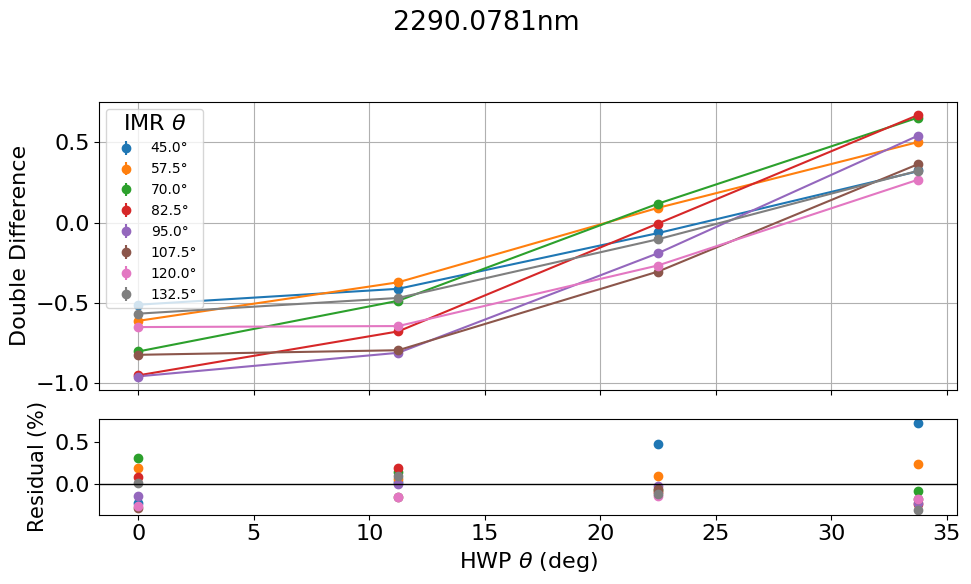

Updated Mueller Matrix:
[[ 0.6431073  -0.6431073   0.          0.        ]
 [-0.63650286  0.63650286  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.30945389944076496 0.715351481495567
s_res: 0.2419545225364087
Error: [0.00117362 0.00073405 0.00158054 0.00258797 0.0009086 ]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.9372e-01                                    7.81e+00    
       1              2         2.5223e-03      2.91e-01       3.06e-01       8.90e-01    
       2              3         1.7378e-04      2.35e-03       2.28e-02       9.83e-04    
       3              4         1.2201e-04      5.18e-05       5.97e-03       4.78e-05    
       4              5         1.2178e-04      2.29e-07       3.84e-04       2.98e-07    
       5              6         1.2178e-04      6.87e-12       1.80e-06 

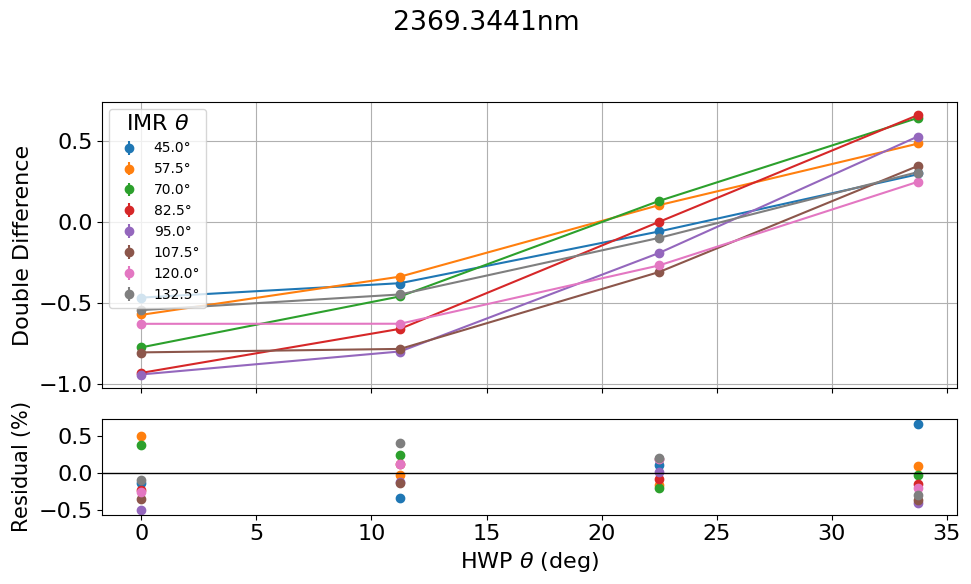

Updated Mueller Matrix:
[[ 0.62963331 -0.62963331  0.          0.        ]
 [-0.61792785  0.61792785  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.5054814600240718 0.6707268329731555
s_res: 0.3003478979075681
Error: [0.00143215 0.00093455 0.00194154 0.00319382 0.00113083]


In [7]:
# Fit all 22 wavelength bins
from pyPolCal.instruments import fit_CHARIS_Mueller_matrix_by_bin
from pathlib import Path
errors = []
sres_list = []
for bin in range(0,22):
    error,fig,ax,sres = fit_CHARIS_Mueller_matrix_by_bin(
        f'../datacsvs/pre_nbs_internalcal_pol_pick_in/bin{bin}.csv',bin,
        Path(f'../fitted_p_dicts/internalcal_july2025_pickin/bin{bin}.json'),
    )
    errors.append(error)
    sres_list.append(sres)



In [8]:
# find average error
import numpy as np
errors = np.array(errors)
print('phi_h', np.mean(errors[:,0]))
print('phi_45',np.mean(errors[:,1]))
print('phi_r',np.mean(errors[:,2]))
print('wol_eta',np.mean(errors[:,3]))




    

phi_h 0.0029879516752993386
phi_45 0.005294334771872206
phi_r 0.0033339667278775003
wol_eta 0.006373417861929085


`model_data` will list out all of your fits in a data frame.

In [11]:
from pyPolCal.csv_tools import model_data
json_dir = '../fitted_p_dicts/internalcal_july2025_pickin'
df = model_data(json_dir, offsets=False)

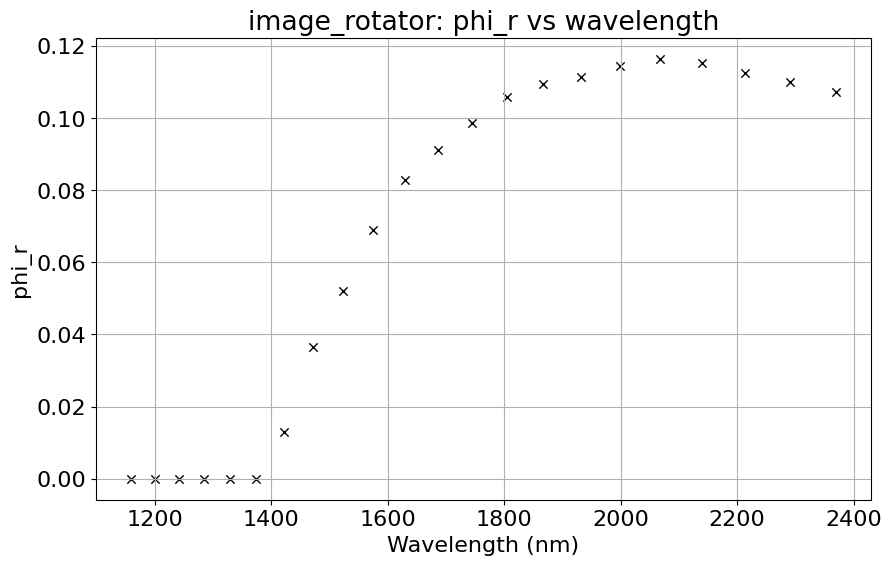

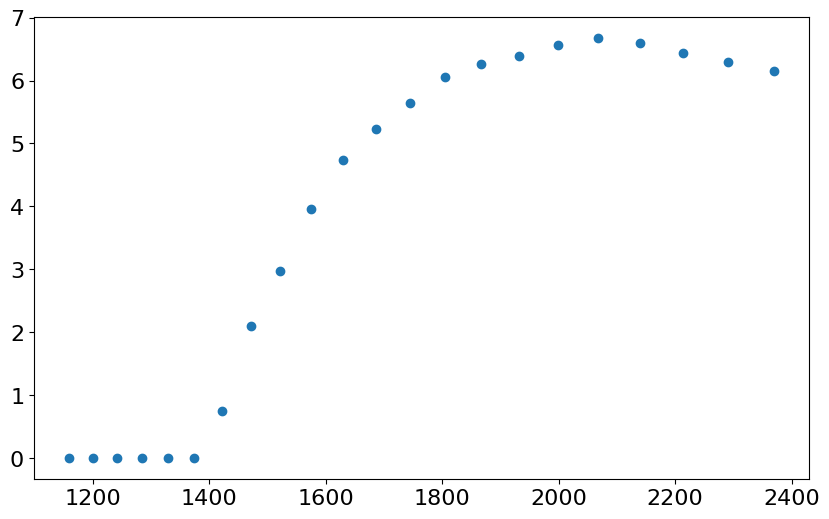

In [12]:
# plot 45 degree linear retardance
from pyPolCal.plotting import plot_config_dict_vs_wavelength
params, fig, ax = plot_config_dict_vs_wavelength('image_rotator', 'phi_r', json_dir)
fig, ax = plt.subplots(figsize=(10,6))
# plot in degrees
ax.scatter(wavelength_bins, np.rad2deg(params))

# Step 4: Fit for Global Parameters

In [13]:
# define custom mm functions
from pyPolCal.mm_registry import register_mm_function
from pyMuellerMat.common_mm_functions import elliptical_retarder_function

wavelength_fits_dir = '../fitted_p_dicts/internalcal_july2025_pickin' # path to fitted p dicts
wavelength_fits_df = model_data(wavelength_fits_dir) # saving to DataFrame
derotator_phi_h = wavelength_fits_df['image_rotator_phi_h'].to_numpy() # linear h retardance
derotator_phi_45 = wavelength_fits_df['image_rotator_phi_45'].to_numpy() # linear 45 retardance
derotator_phi_r = wavelength_fits_df['image_rotator_phi_r'].to_numpy() # circular retardance
wollaston_eta = wavelength_fits_df['wollaston_eta'].to_numpy()

@register_mm_function()
def fitted_derotator_function_july_2025_pickin(wavelength=500): # Only keyword arguments!
    phi_h = derotator_phi_h
    phi_45 = derotator_phi_45
    phi_r = derotator_phi_r

    # Interpolating retardance as a function of wavelength 
    phi_h_interp = np.interp(wavelength, wavelength_bins, phi_h)
    phi_45_interp = np.interp(wavelength, wavelength_bins, phi_45)
    phi_r_interp = np.interp(wavelength, wavelength_bins, phi_r)

    # using pyMuellerMat's elliptical retarder function
    return elliptical_retarder_function(phi_h_interp, phi_45_interp, phi_r_interp)

@register_mm_function()
def fitted_wollaston_function_july_2025_pickin(beam='o',wavelength=500): # Only keyword arguments!
    eta = wollaston_eta

    # Interpolating retardance as a function of wavelength
    eta_interp = np.interp(wavelength, wavelength_bins, eta)

    # using pyMuellerMat's elliptical retarder function
    return wollaston_prism_function(beam=beam,eta=eta_interp)

In [14]:
# Get interleaved values for all wavelength bins
csvdir = Path('../datacsvs/pre_nbs_internalcal_pol_pick_in')

interleaved_values_all, interleaved_stds_all, configuration_list_all = read_csv_physical_model_all_bins(csvdir)

from pyPolCal.constants import wavelength_bins
wavelength_bin = 15 # placeholder
epsilon_cal = -1 # defining as perfect, reasoning in Joost t Hart 2021
offset_imr = -0.0018
offset_hwp = -0.0022 
offset_cal = -0.0315 
imr_theta = 0 # placeholder 
hwp_theta = 0 # placeholder
# Past fits from scipy minimize on the naive fits
d = 259.7
wsio2 = 1.613
wmgf2 = 1.261

# Define instrument configuration as system dictionary
# Wollaston beam, imr theta/phi, and hwp theta/phi will all be updated within functions, so don't worry about their values here

system_dict = {
"components" : {
    "wollaston" : {
        "type" : "fitted_wollaston_function_july_2025_pickin",
        "properties" : {"wavelength": wavelength_bins[wavelength_bin], "beam": 'o'}, 
        "tag": "internal",
    },

    "image_rotator" : {
        "type" : "fitted_derotator_function_july_2025_pickin",
        "properties" : {"wavelength":wavelength_bins[wavelength_bin], "theta": imr_theta, "delta_theta": offset_imr},
        "tag": "internal",
    },
    "hwp" : {
        "type" : "two_layer_HWP_function",
        "properties" : {"wavelength": wavelength_bins[wavelength_bin], "w_SiO2": wsio2, "w_MgF2": wmgf2, "theta":hwp_theta, "delta_theta": offset_hwp},
        "tag": "internal",
    },
    "lp" : {  # calibration polarizer for internal calibration source
        "type": "diattenuator_retarder_function",
        "properties": {"epsilon": epsilon_cal, "delta_theta": 0},
        "tag": "internal",
    }}
}
    
# Starting guesses

p0_dict = {
    "image_rotator" : 
        {"delta_theta": offset_imr},
    "hwp" :  
        {"w_SiO2": wsio2, "w_MgF2": wmgf2, "delta_theta": offset_hwp},
    "lp" : 
        {"delta_theta": offset_cal},
}

system_mm = generate_system_mueller_matrix(system_dict) # Generating pyMuellerMat system MM
print(system_mm.evaluate())
p0 = [1.623, 1.268, 262.56] # Starting guesses from Joost t Hart 2021 
offset_bounds = (-5,5) 
d_bounds = (0.8*p0[2], 1.2*p0[2]) # Physical parameters shouldn't have changed much
imr_offset_bounds = offset_bounds
wsio2_bounds = (0.6*p0[0], 1.4*p0[0])
wmgf2_bounds = (0.6*p0[1], 1.4*p0[1])
bounds=[offset_bounds,wsio2_bounds,wmgf2_bounds,offset_bounds,offset_bounds]
# Process everything into double differences and propagate errors





[[ 0.00767445 -0.00767445  0.          0.        ]
 [-0.00109369  0.00109369  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]


In [15]:
# Minimize everything globally with minimize
from pyPolCal.fitting import minimize_system_mueller_matrix
result_min, logl_min=minimize_system_mueller_matrix(p0_dict,system_mm,interleaved_values_all,
                               configuration_list_all,s_in=[1,0,0,0],process_dataset=process_dataset,
                               process_errors=process_errors, process_model=process_model,include_sums=False,
                               bounds=bounds,mode='minimize')
print(result_min)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.01824032155191856
        x: [-4.407e-02  1.635e+00  1.278e+00 -3.690e-02 -8.406e-03]
      nit: 33
      jac: [-9.871e-05  4.420e-03 -5.770e-03 -3.632e-04 -7.290e-04]
     nfev: 252
     njev: 42
 hess_inv: <5x5 LbfgsInvHessProduct with dtype=float64>
